In [28]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the Excel file
file_path = 'dv0_witoutstraw.xlsx'  # Use the correct path for your environment
data = pd.read_excel(file_path)
# print("Columns in the dataset:")
# print(data.columns.tolist())
# Display the first few rows of the dataset to understand its structure
# print("Original Data Sample:")

df = data[data['Label'] == 1]
df['Gender'] = df["Gender"].map({"Male": 1, "Female": 0})

df["Container_Weight"] = df["Container_Weight"].map({
    7.7: 0,
    10.6: 1,
    10.9: 1,  
    12.7: 2,
    19.8: 3,
    359: 4
})
# df["Container_Weight"] = df["Container_Weight"].map({
#     7.7: 0,   # First type
#     10.6: 1,  # Second type
#     10.9: 2,  # Changed this to represent a distinct type
#     12.7: 3,  # Third type
#     19.8: 4,  # Fourth type
#     359: 5    # Fifth type
# })
df["Label"] = df["Label"].map({"Drinking": 1, "Not_Drinking": 0})
df['temp'] = df ['temp'].map({'h':2, 'c':0, 'n': 1})
# print(data.head())
# Group by Participant_ID and sip_id to count time steps and extract dV and Label
grouped_data = df.groupby(['Participant_ID', 'sip_id']).agg(
    time_steps=('sip_id', 'size'),  # Count of rows (time steps)
    dV=('dV', 'first'),  # Taking the first dV value for each group
    Gender=('Gender', 'first'), 
    temp=('temp', 'first') ,
    Container_Weight=('Container_Weight', 'first'),
    Label=('Label', 'first')  # Assuming the label is consistent, take the first
).reset_index()


# Merge SIP_TIME back to the grouped data
# grouped_data = pd.merge(grouped_data, sip_counts, on='sip_id', how='left').fillna(0)
# grouped_data['SIP_TIME'] = grouped_data['SIP_TIME'].astype(int)
# Display the grouped data before creating X and y
print("\nGrouped Data Sample:")
print(grouped_data.head())
# grouped_data.to_excel('dv0_witoutstraw_final.xlsx')
# Prepare features (X) and target (y)
X = grouped_data[['time_steps','Gender', 'Container_Weight','temp', 'sip_id']]  # Features
y = grouped_data['dV']             # Target variable

# Display X and y before proceeding
print("\nFeatures (X):")
print(X.head(50))
print("\nTarget (y):")
print(y.head(50))

# Split the data into training and testing sets (optional)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Now you can proceed with training your model using X and y as needed


Grouped Data Sample:
   Participant_ID  sip_id  time_steps         dV  Gender  temp  \
0               6       1          26  69.904762       1     0   
1               6       2          26  58.000000       1     0   
2               6       3          27  61.904762       1     0   
3               6       4          29  68.857143       1     0   
4               6       5          23  44.571429       1     0   

   Container_Weight  Label  
0                 3    NaN  
1                 3    NaN  
2                 3    NaN  
3                 3    NaN  
4                 3    NaN  

Features (X):
    time_steps  Gender  Container_Weight  temp  sip_id
0           26       1                 3     0       1
1           26       1                 3     0       2
2           27       1                 3     0       3
3           29       1                 3     0       4
4           23       1                 3     0       5
5           13       1                 3     0       6
6      

/var/folders/s7/ddngkscs167c_65wscck142m0000gr/T/ipykernel_18467/3241041800.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Gender'] = df["Gender"].map({"Male": 1, "Female": 0})
/var/folders/s7/ddngkscs167c_65wscck142m0000gr/T/ipykernel_18467/3241041800.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Container_Weight"] = df["Container_Weight"].map({
/var/folders/s7/ddngkscs167c_65wscck142m0000gr/T/ipykernel_18467/3241041800.py:31: SettingWithCopyWarning: 
A value is trying to be set on a c

In [29]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
# from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor

from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor

In [30]:
train_size = int(0.8 * len(grouped_data))  # 80% of the data for training
X_train = X.iloc[:train_size]
y_train = y.iloc[:train_size]
X_test = X.iloc[train_size:]
y_test = y.iloc[train_size:]


In [10]:

# Create a Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)




In [7]:
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

In [8]:
model = SVR(kernel='poly')
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

In [9]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

In [10]:
model = GradientBoostingRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

In [11]:
model = XGBRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

NameError: name 'XGBRegressor' is not defined

In [ ]:
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
rmspe = np.sqrt(np.mean(((y_test - y_pred) / y_test) ** 2)) * 100  # Percentage error

# Print evaluation metrics
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R²): {r2:.4f}")
print(f"Root Mean Squared Percentage Error (RMSPE): {rmspe:.4f}%")
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(comparison_df.head(50))
# Plot Actual vs Predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', ls='--', label='Perfect Prediction')
plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')
plt.title('Actual vs Predicted Drinking Volume')
plt.legend()
plt.grid()
plt.show()

In [ ]:
# plt.figure(figsize=(10, 6))
# plt.scatter(X, y, color='blue', label='Predicted vs Actual', alpha=0.6)
# # plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', ls='--', label='Perfect Prediction')
# plt.xlabel('timestamp')
# plt.ylabel('Volume')
# plt.title('All data plot')
# plt.legend()
# plt.grid()
# plt.show()


Linear Regression Evaluation Metrics:
Mean Squared Error (MSE): 500.9922
Root Mean Squared Error (RMSE): 22.3829
R-squared (R²): -0.6121
Root Mean Squared Percentage Error (RMSPE): 62.2958%
     Actual  Predicted
252    38.1  19.009093
253    36.0  18.028517
254    33.7  17.047941
255    23.0  19.632331
256    13.9  13.049666


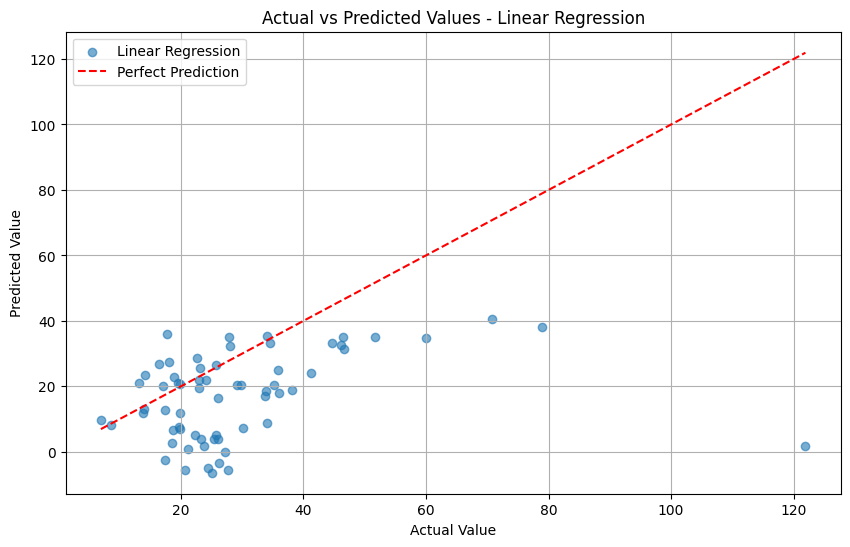


Support Vector Regression Evaluation Metrics:
Mean Squared Error (MSE): 398.6271
Root Mean Squared Error (RMSE): 19.9656
R-squared (R²): -0.2827
Root Mean Squared Percentage Error (RMSPE): 47.9482%
     Actual  Predicted
252    38.1  20.090523
253    36.0  19.794581
254    33.7  19.512280
255    23.0  22.646386
256    13.9  17.574730


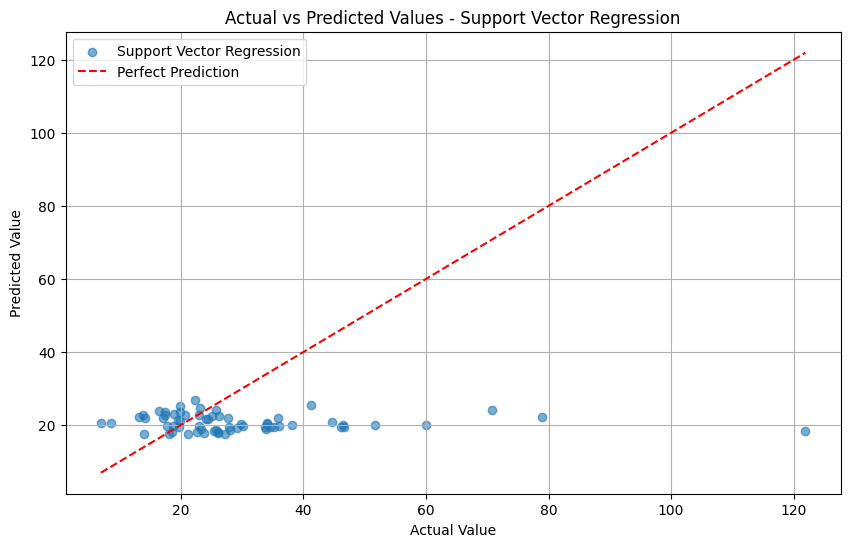


Decision Tree Evaluation Metrics:
Mean Squared Error (MSE): 731.4507
Root Mean Squared Error (RMSE): 27.0453
R-squared (R²): -1.3537
Root Mean Squared Percentage Error (RMSPE): 92.5123%
     Actual  Predicted
252    38.1       18.7
253    36.0       18.7
254    33.7       18.7
255    23.0       18.7
256    13.9       18.7


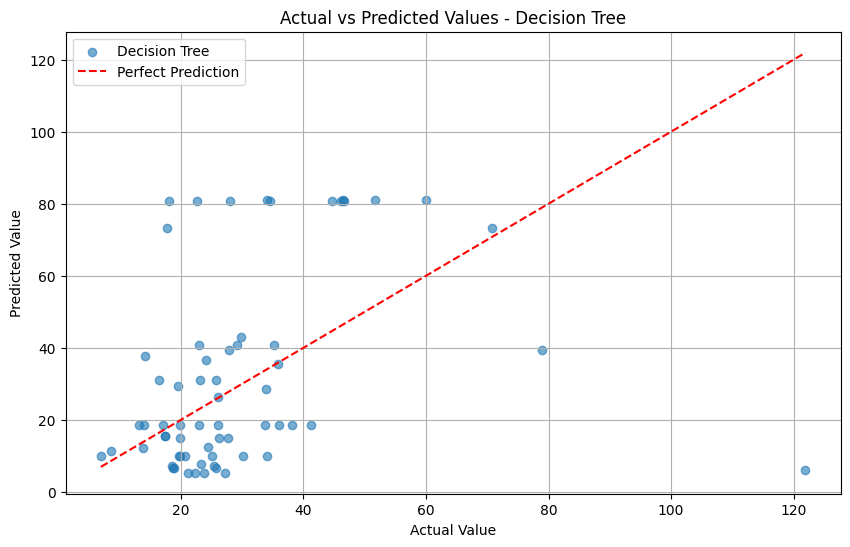


Random Forest Evaluation Metrics:
Mean Squared Error (MSE): 398.9677
Root Mean Squared Error (RMSE): 19.9742
R-squared (R²): -0.2838
Root Mean Squared Percentage Error (RMSPE): 62.5473%
     Actual  Predicted
252    38.1  24.232000
253    36.0  24.277868
254    33.7  24.225959
255    23.0  38.022183
256    13.9  22.834085


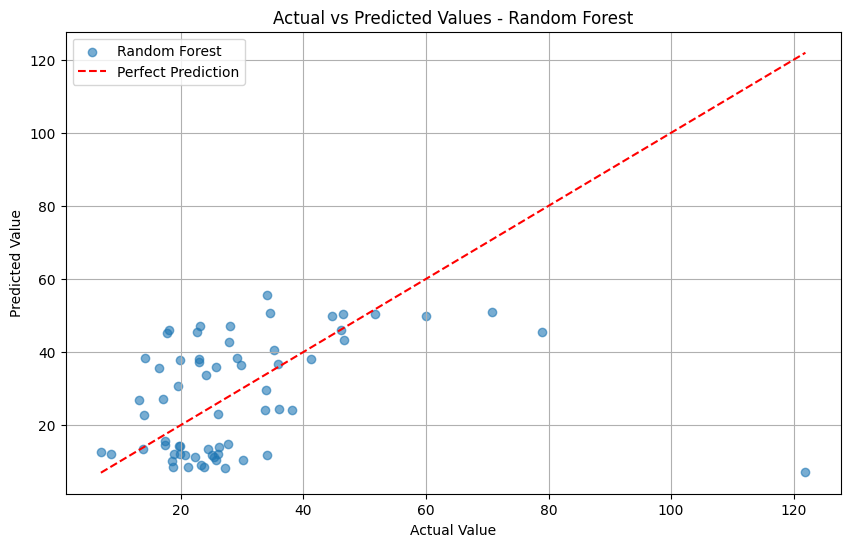


Gradient Boosting Evaluation Metrics:
Mean Squared Error (MSE): 396.9903
Root Mean Squared Error (RMSE): 19.9246
R-squared (R²): -0.2774
Root Mean Squared Percentage Error (RMSPE): 65.6818%
     Actual  Predicted
252    38.1  28.496063
253    36.0  27.319728
254    33.7  27.319728
255    23.0  33.577415
256    13.9  27.446347


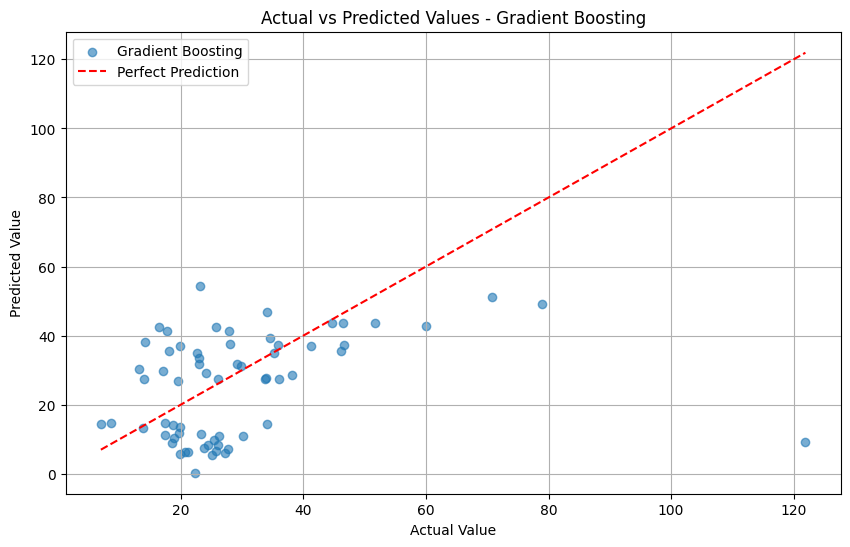


K-Nearest Neighbors Evaluation Metrics:
Mean Squared Error (MSE): 432.8618
Root Mean Squared Error (RMSE): 20.8053
R-squared (R²): -0.3929
Root Mean Squared Percentage Error (RMSPE): 57.5215%
     Actual  Predicted
252    38.1  28.568548
253    36.0  21.207742
254    33.7  21.137820
255    23.0  25.355865
256    13.9  24.156598


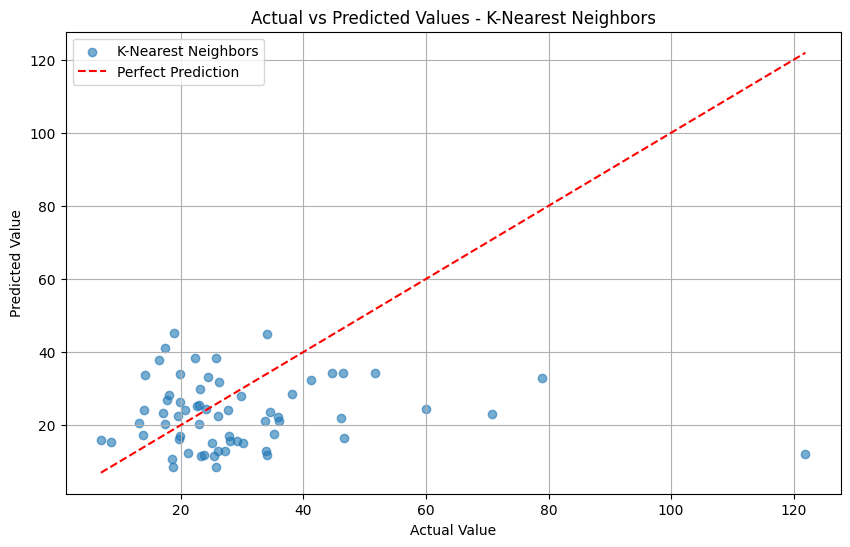

In [12]:
models = {
    "Linear Regression": LinearRegression(),
    "Support Vector Regression": SVR(kernel='rbf'),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    # "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=5),
}

# Store evaluation results
results = {}

for model_name, model in models.items():
    # Fit the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    rmspe = np.sqrt(np.mean(((y_test - y_pred) / y_test) ** 2)) * 100  # Percentage error

    # Store results in a dictionary
    results[model_name] = {
        'MSE': mse,
        'RMSE': rmse,
        'R^2': r2,
        'RMSPE': rmspe,
        'Predictions': y_pred
    }

    # Print evaluation metrics for the model
    print(f"\n{model_name} Evaluation Metrics:")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"R-squared (R²): {r2:.4f}")
    print(f"Root Mean Squared Percentage Error (RMSPE): {rmspe:.4f}%")

    # Create a comparison DataFrame for the first few rows
    comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
    print(comparison_df.head(5))

    # Plotting Actual vs Predicted
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred, label=model_name, alpha=0.6)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', ls='--', label='Perfect Prediction')
    plt.xlabel('Actual Value')
    plt.ylabel('Predicted Value')
    plt.title(f'Actual vs Predicted Values - {model_name}')
    plt.legend()
    plt.grid()
    plt.show()


Linear Regression Evaluation Metrics:
Mean Squared Error (MSE): 500.9922
Root Mean Squared Error (RMSE): 22.3829
R-squared (R²): -0.6121
Root Mean Squared Percentage Error (RMSPE): 62.2958%


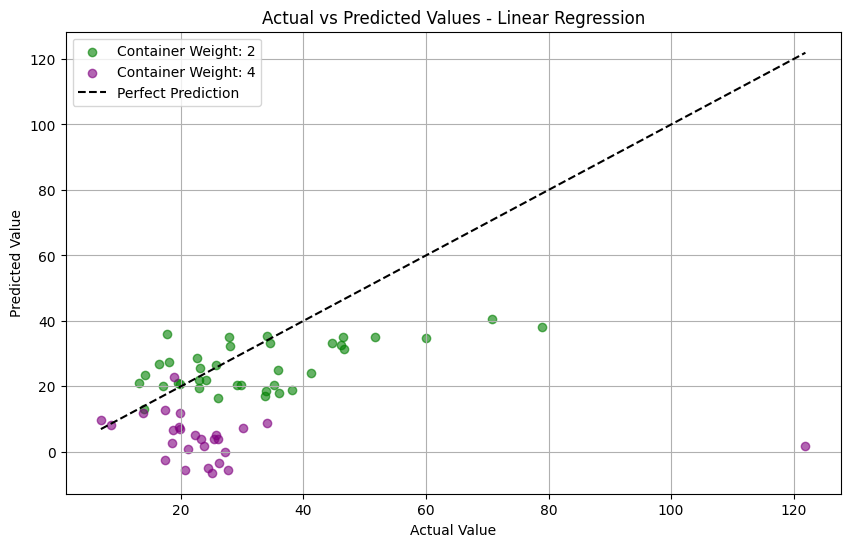


Support Vector Regression Evaluation Metrics:
Mean Squared Error (MSE): 398.6271
Root Mean Squared Error (RMSE): 19.9656
R-squared (R²): -0.2827
Root Mean Squared Percentage Error (RMSPE): 47.9482%


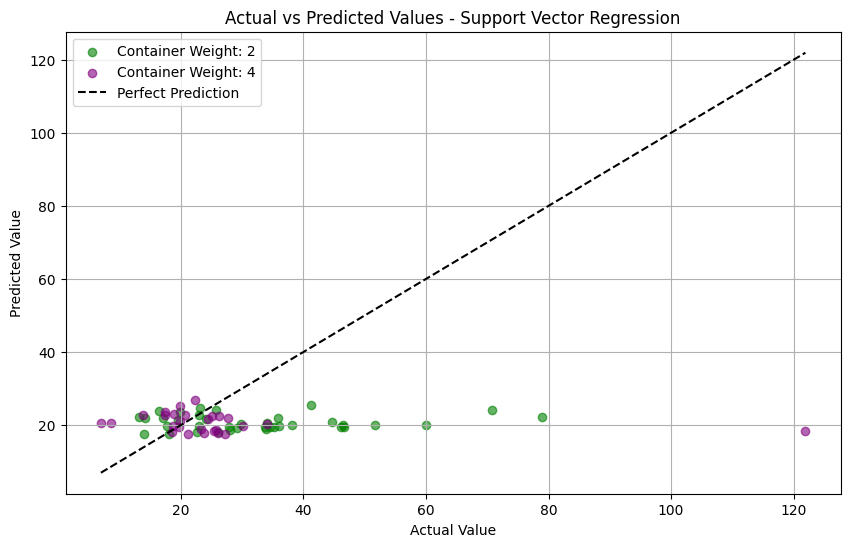


Decision Tree Evaluation Metrics:
Mean Squared Error (MSE): 731.4507
Root Mean Squared Error (RMSE): 27.0453
R-squared (R²): -1.3537
Root Mean Squared Percentage Error (RMSPE): 92.5123%


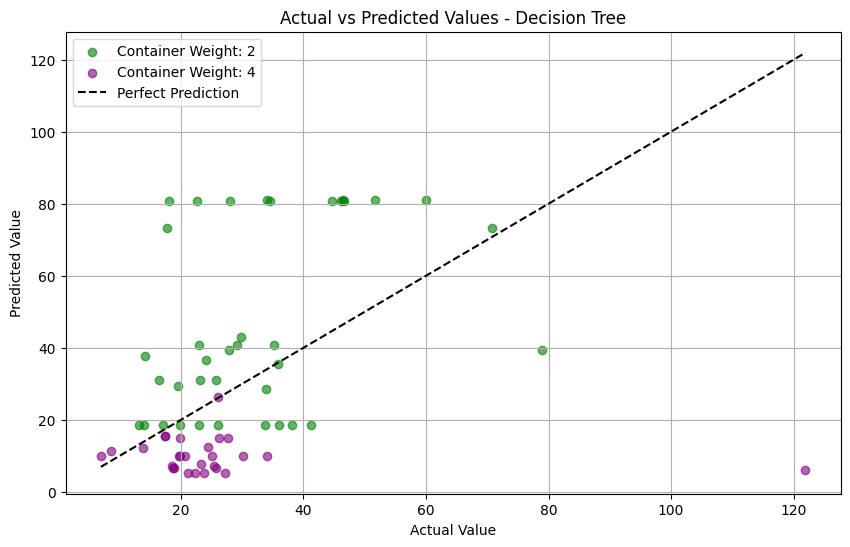


Random Forest Evaluation Metrics:
Mean Squared Error (MSE): 398.9677
Root Mean Squared Error (RMSE): 19.9742
R-squared (R²): -0.2838
Root Mean Squared Percentage Error (RMSPE): 62.5473%


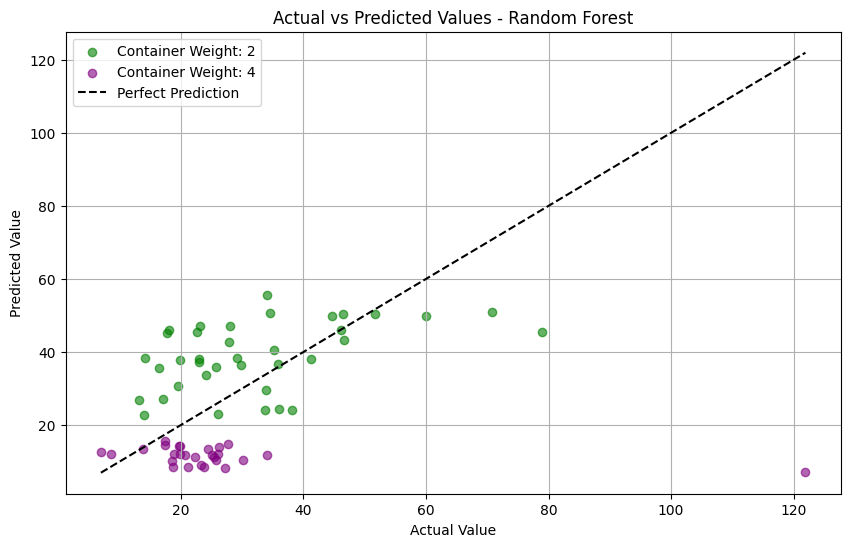


Gradient Boosting Evaluation Metrics:
Mean Squared Error (MSE): 396.9903
Root Mean Squared Error (RMSE): 19.9246
R-squared (R²): -0.2774
Root Mean Squared Percentage Error (RMSPE): 65.6818%


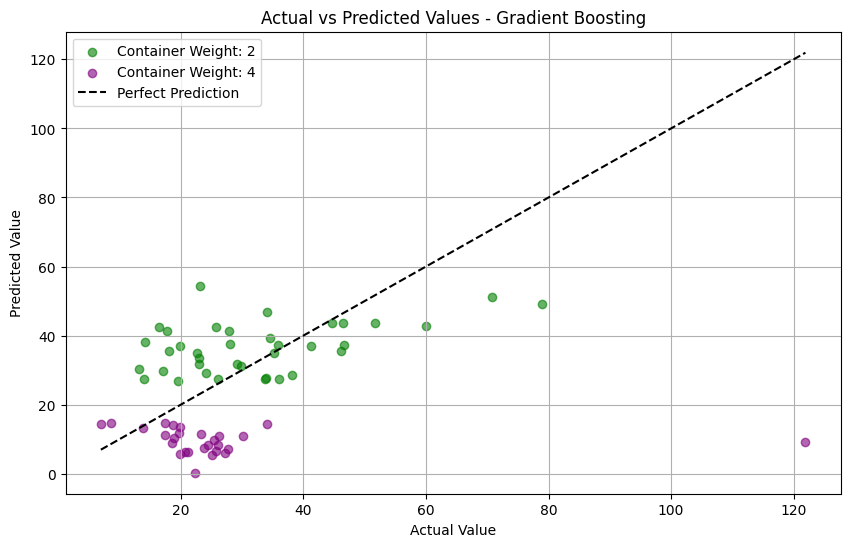


K-Nearest Neighbors Evaluation Metrics:
Mean Squared Error (MSE): 432.8618
Root Mean Squared Error (RMSE): 20.8053
R-squared (R²): -0.3929
Root Mean Squared Percentage Error (RMSPE): 57.5215%


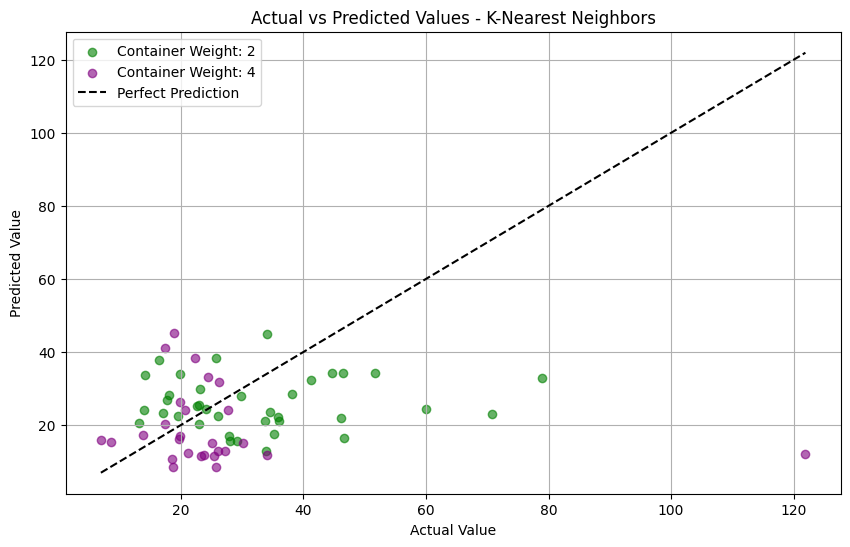

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming you have already defined your models and results above
# color_map = {
#     0: 'blue',
#     1: 'orange',
#     2: 'green',
#     3: 'red',
#     4: 'purple'
# }
color_map = {
    0: 'blue',    # For 7.7
    1: 'orange',  # For 10.6
    2: 'green',   # For 10.9
    3: 'red',     # For 12.7
    4: 'purple',  # For 19.8
    5: 'cyan'     # For 359
}
# Store evaluation results
results = {}

for model_name, model in models.items():
    # Fit the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    rmspe = np.sqrt(np.mean(((y_test - y_pred) / y_test) ** 2)) * 100  # Percentage error

    # Store results in a dictionary
    results[model_name] = {
        'MSE': mse,
        'RMSE': rmse,
        'R^2': r2,
        'RMSPE': rmspe,
        'Predictions': y_pred
    }

    # Print evaluation metrics for the model
    print(f"\n{model_name} Evaluation Metrics:")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"R-squared (R²): {r2:.4f}")
    print(f"Root Mean Squared Percentage Error (RMSPE): {rmspe:.4f}%")

    comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred, 'Container_Weight': X_test['Container_Weight']})
    
    # Plotting Actual vs Predicted with Container Weights
    plt.figure(figsize=(10, 6))

    for weight, group in comparison_df.groupby('Container_Weight'):
        plt.scatter(group['Actual'], group['Predicted'], 
                    label=f'Container Weight: {weight}', 
                    color=color_map[weight], 
                    alpha=0.6)
# Assuming you use the updated color mapping provided above
# for weight, group in comparison_df.groupby('Container_Weight'):
#     plt.scatter(group['Actual'], group['Predicted'], 
#                 label=f'Container Weight: {weight}', 
#                 color=color_map[weight], 
#                 alpha=0.6)
    plt.plot([comparison_df['Actual'].min(), comparison_df['Actual'].max()],
             [comparison_df['Actual'].min(), comparison_df['Actual'].max()],
             color='black', ls='--', label='Perfect Prediction')

    plt.xlabel('Actual Value')
    plt.ylabel('Predicted Value')
    plt.title(f'Actual vs Predicted Values - {model_name}')
    plt.legend()
    plt.grid()
    plt.show()

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor

# Assuming df is your DataFrame that contains 'Container_Weight' and your feature columns
# Mapping container weights to classes
df["Container_Weight"] = df["Container_Weight"].map({
    7.7: 0,
    10.6: 1,
    10.9: 1,  
    12.7: 2,
    19.8: 3,
    359: 4
})

# Assuming X_train and y_train are defined properly from your df DataFrame
# Define features and target variable
  # Replace with your actual target column name

# Store results for all model evaluations
overall_results = {}

# Get unique container weight classes
weight_classes = df["Container_Weight"].unique()

for category in weight_classes:
    # Filter data based on container weight class
    mask = df["Container_Weight"] == category
    X_filtered = X_train[mask]
    y_filtered = y_train[mask]

    if len(y_filtered) == 0:
        print(f"No data available for container weight category: {category}.")
        continue

    print(f"Training models for container weight category: {category}...")

    # Define your models
    models = {
        "Linear Regression": LinearRegression(),
        "Support Vector Regression": SVR(kernel='rbf'),
        "Decision Tree": DecisionTreeRegressor(random_state=42),
        "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
        "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
        "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=5),
    }

    # Store evaluation results for this category
    results = {}

for category in weight_classes:
    # Filter data based on container weight class
    filtered_data = df[df["Container_Weight"] == category]
    
    # Check if the filtered data is not empty
    if len(filtered_data) == 0:
        print(f"No data available for container weight category: {category}.")
        continue

    # Split filtered data into features and target
    X_filtered = filtered_data[feature_columns]
    y_filtered = filtered_data[target_column]

    print(f"Training models for container weight category: {category}...")

    # Define your models
    models = {
        "Linear Regression": LinearRegression(),
        "Support Vector Regression": SVR(kernel='rbf'),
        "Decision Tree": DecisionTreeRegressor(random_state=42),
        "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
        "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
        "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=5),
    }

    # Store evaluation results for this category
    results = {}

    for model_name, model in models.items():
        # Fit the model
        model.fit(X_filtered, y_filtered)

        # Make predictions using the filtered data
        y_pred = model.predict(X_filtered)  # Using the same filtered data for prediction

        # Calculate evaluation metrics
        mse = mean_squared_error(y_filtered, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_filtered, y_pred)
        rmspe = np.sqrt(np.mean(((y_filtered - y_pred) / y_filtered) ** 2)) * 100  # Percentage error

        # Store results in a dictionary
        results[model_name] = {
            'MSE': mse,
            'RMSE': rmse,
            'R^2': r2,
            'RMSPE': rmspe,
            'Predictions': y_pred
        }

        # Print evaluation metrics for the model
        print(f"\n{model_name} Evaluation Metrics for Container Weight Category {category}:")
        print(f"Mean Squared Error (MSE): {mse:.4f}")
        print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
        print(f"R-squared (R²): {r2:.4f}")
        print(f"Root Mean Squared Percentage Error (RMSPE): {rmspe:.4f}%")

        # Create a comparison DataFrame for the first few rows
        comparison_df = pd.DataFrame({'Actual': y_filtered, 'Predicted': y_pred})
        print(comparison_df.head(5))

        # Plotting Actual vs Predicted
        plt.figure(figsize=(10, 6))
        plt.scatter(y_filtered, y_pred, label=model_name, alpha=0.6)
        plt.plot([y_filtered.min(), y_filtered.max()], [y_filtered.min(), y_filtered.max()], color='red', ls='--', label='Perfect Prediction')
        plt.xlabel('Actual Value')
        plt.ylabel('Predicted Value')
        plt.title(f'Actual vs Predicted Values - {model_name} (Container Weight {category})')
        plt.legend()
        plt.grid()
        plt.show()
    
    # Store results for overall overview
    overall_results[category] = results

print("Model evaluations completed for all container weight categories.")
    

/var/folders/s7/ddngkscs167c_65wscck142m0000gr/T/ipykernel_18467/4077206475.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Container_Weight"] = df["Container_Weight"].map({
/var/folders/s7/ddngkscs167c_65wscck142m0000gr/T/ipykernel_18467/4077206475.py:35: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X_filtered = X_train[mask]


IndexingError: Unalignable boolean Series provided as indexer (index of the boolean Series and of the indexed object do not match).

In [26]:
df["Container_Weight"]

241     NaN
242     NaN
243     NaN
244     NaN
245     NaN
         ..
79927   NaN
79928   NaN
79929   NaN
79930   NaN
79931   NaN
Name: Container_Weight, Length: 5345, dtype: float64

     time_steps  Gender  Container_Weight  temp  sip_id
131          19       1                 2     0       1
132          30       1                 2     0       2
133          18       1                 2     0       3
134          17       1                 2     0       4
135          12       1                 2     0       5
136          29       1                 2     0       6
137          21       1                 2     0       7
138          26       1                 2     0       8
139          17       1                 2     0       9
148          12       0                 2     1       1
149          14       0                 2     1       2
150          14       0                 2     1       3
151          15       0                 2     1       4
152          17       0                 2     1       5
153          17       0                 2     1       6
154          12       0                 2     1       7
229          22       1                 2     1 

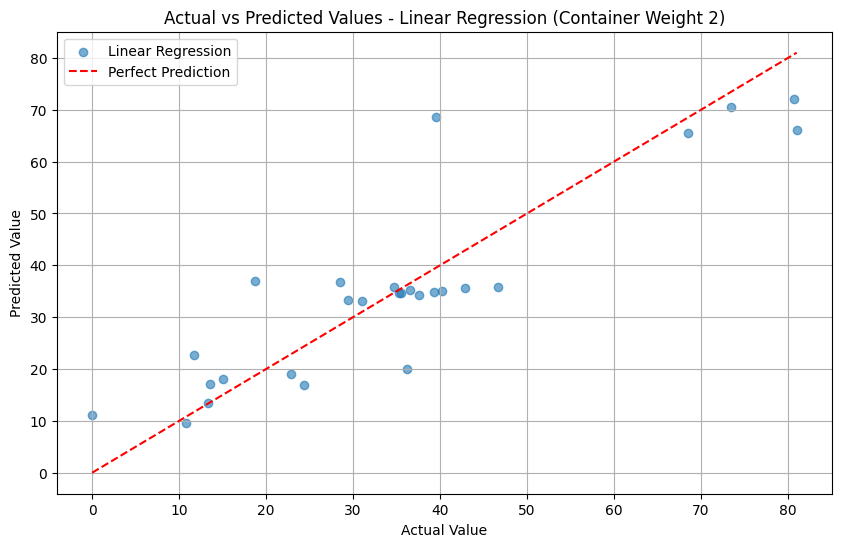


Support Vector Regression Evaluation Metrics for Container Weight Category 2:
Mean Squared Error (MSE): 419.4148
Root Mean Squared Error (RMSE): 20.4796
R-squared (R²): 0.0046
Root Mean Squared Percentage Error (RMSPE): inf%
        Actual  Predicted
131  13.516161  35.268747
132  10.773751  35.053653
133  15.083252  35.111541
134  22.918707  35.037028
135  11.655240  35.023682


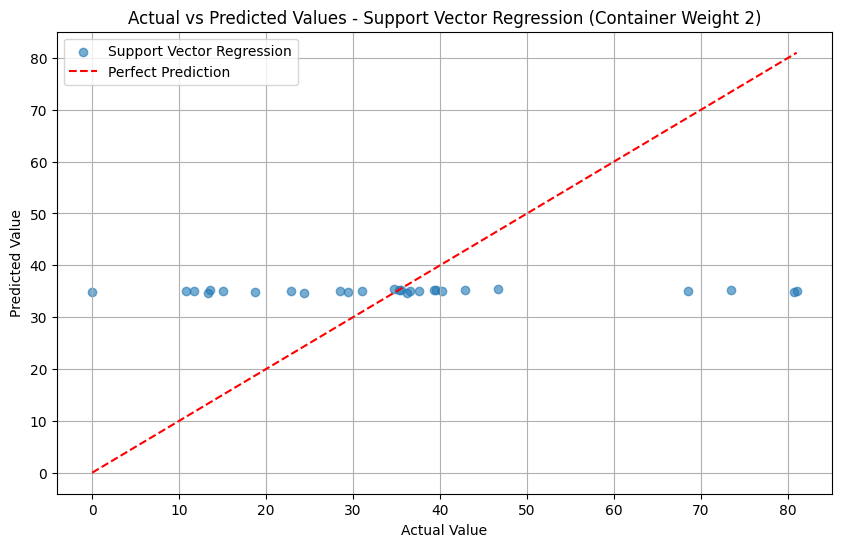


Decision Tree Evaluation Metrics for Container Weight Category 2:
Mean Squared Error (MSE): 2.6674
Root Mean Squared Error (RMSE): 1.6332
R-squared (R²): 0.9937
Root Mean Squared Percentage Error (RMSPE): 4.2254%
        Actual  Predicted
131  13.516161  13.516161
132  10.773751  10.773751
133  15.083252  15.083252
134  22.918707  22.918707
135  11.655240  11.655240


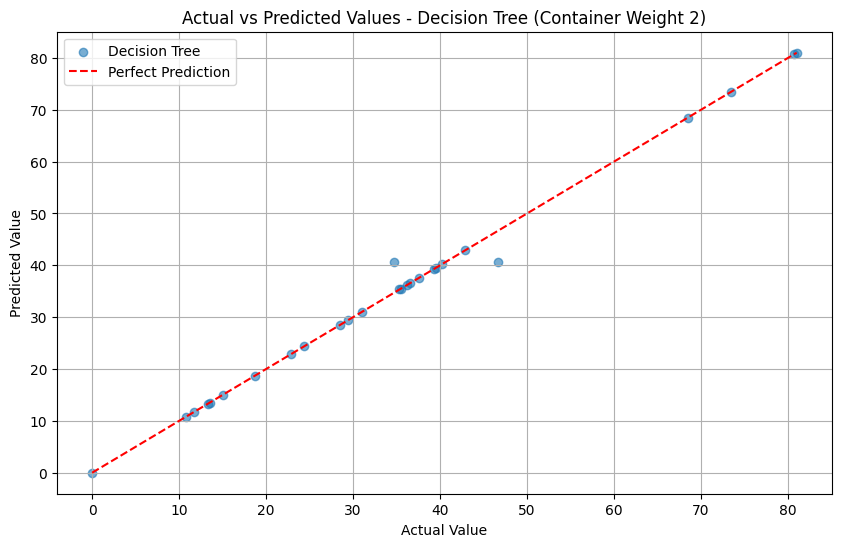


Random Forest Evaluation Metrics for Container Weight Category 2:
Mean Squared Error (MSE): 32.1976
Root Mean Squared Error (RMSE): 5.6743
R-squared (R²): 0.9236
Root Mean Squared Percentage Error (RMSPE): inf%
        Actual  Predicted
131  13.516161  16.371742
132  10.773751  18.410068
133  15.083252  18.458548
134  22.918707  20.631050
135  11.655240  15.321518


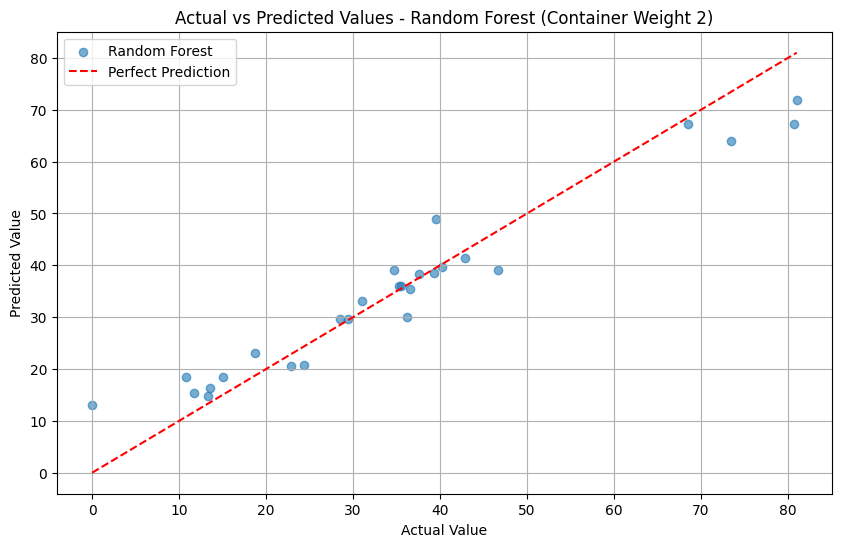


Gradient Boosting Evaluation Metrics for Container Weight Category 2:
Mean Squared Error (MSE): 2.8986
Root Mean Squared Error (RMSE): 1.7025
R-squared (R²): 0.9931
Root Mean Squared Percentage Error (RMSPE): inf%
        Actual  Predicted
131  13.516161  13.626898
132  10.773751  10.700479
133  15.083252  15.478604
134  22.918707  22.375492
135  11.655240  11.973102


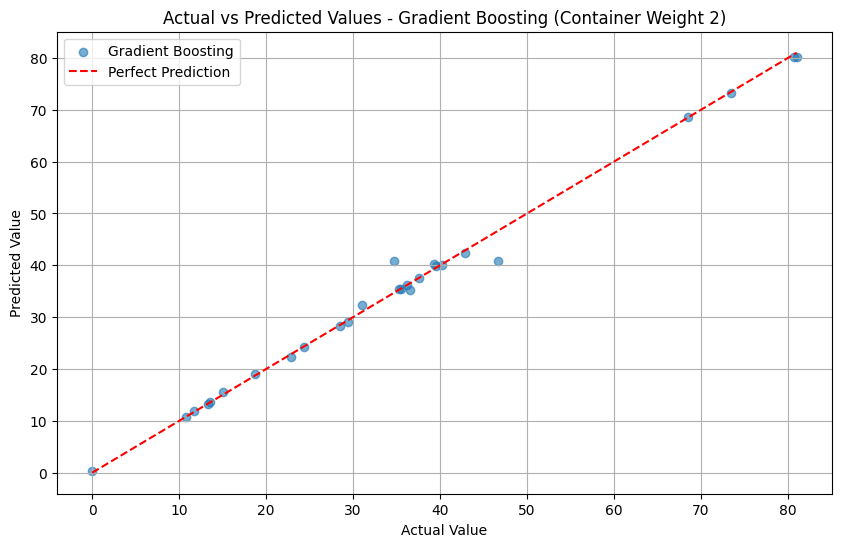


K-Nearest Neighbors Evaluation Metrics for Container Weight Category 2:
Mean Squared Error (MSE): 340.5097
Root Mean Squared Error (RMSE): 18.4529
R-squared (R²): 0.1918
Root Mean Squared Percentage Error (RMSPE): inf%
        Actual  Predicted
131  13.516161  41.123624
132  10.773751  39.954750
133  15.083252  24.023624
134  22.918707  27.200392
135  11.655240  27.111048


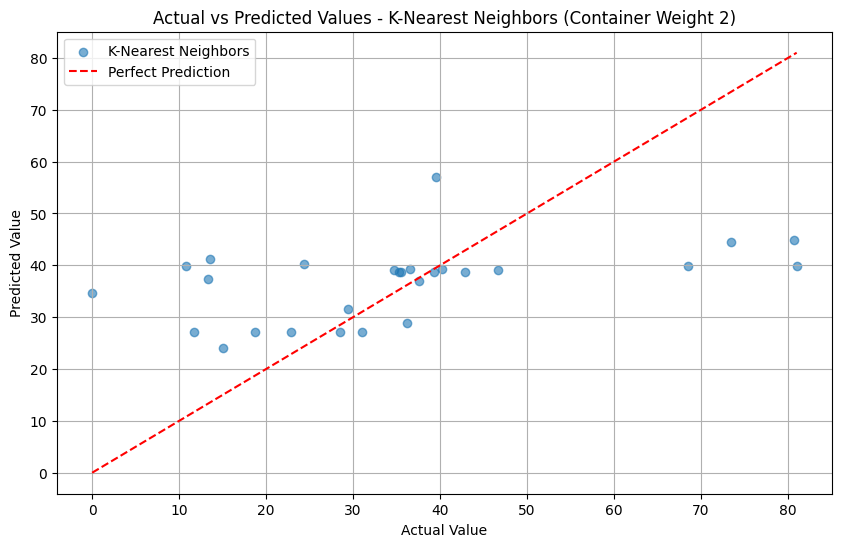

Model evaluations completed for container weight category: 2


In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor


# Models to evaluate
models = {
    "Linear Regression": LinearRegression(),
    "Support Vector Regression": SVR(kernel='rbf'),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=5),
}

# Define the category to filter
category = 2  # Example category to filter by

# Filter X_train based on the Container_Weight column
filtered_X = X_train[X_train["Container_Weight"] == category]
print(filtered_X)
# If you also want to filter the corresponding target variable y_train
filtered_y = y_train.loc[filtered_X.index]

# Check if there are any rows after filtering
if filtered_X.empty or filtered_y.empty:
    print(f"No data available for container weight category: {category}.")
else:
    # Store evaluation results for this category
    results = {}

    for model_name, model in models.items():
        # Fit the model
        model.fit(filtered_X, filtered_y)

        # Make predictions using the filtered data
        y_pred = model.predict(filtered_X)  # Using the same filtered data for prediction

        # Calculate evaluation metrics
        mse = mean_squared_error(filtered_y, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(filtered_y, y_pred)
        rmspe = np.sqrt(np.mean(((filtered_y - y_pred) / filtered_y) ** 2)) * 100  # Percentage error

        # Store results in a dictionary
        results[model_name] = {
            'MSE': mse,
            'RMSE': rmse,
            'R^2': r2,
            'RMSPE': rmspe,
            'Predictions': y_pred
        }

        # Print evaluation metrics for the model
        print(f"\n{model_name} Evaluation Metrics for Container Weight Category {category}:")
        print(f"Mean Squared Error (MSE): {mse:.4f}")
        print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
        print(f"R-squared (R²): {r2:.4f}")
        print(f"Root Mean Squared Percentage Error (RMSPE): {rmspe:.4f}%")

        # Create a comparison DataFrame for the first few rows
        comparison_df = pd.DataFrame({'Actual': filtered_y, 'Predicted': y_pred})
        print(comparison_df.head(5))

        # Plotting Actual vs Predicted
        plt.figure(figsize=(10, 6))
        plt.scatter(filtered_y, y_pred, label=model_name, alpha=0.6)
        plt.plot([filtered_y.min(), filtered_y.max()], [filtered_y.min(), filtered_y.max()], color='red', ls='--', label='Perfect Prediction')
        plt.xlabel('Actual Value')
        plt.ylabel('Predicted Value')
        plt.title(f'Actual vs Predicted Values - {model_name} (Container Weight {category})')
        plt.legend()
        plt.grid()
        plt.show()

print("Model evaluations completed for container weight category:", category)